# TODOs
- identify horizontal lines first
- pick which sections to focus on based on page number (first, last)
- split horizontal blocks with vertical lines

In [1]:
import os
import json
import gc
import cv2
import numpy as np
import re
from pathlib import Path
from pdf2image import convert_from_path
from PIL import Image
import matplotlib.pyplot as plt

constants

In [2]:
DPI = 300
#file_in = "AMD1918_p0571.pdf"
#file_in ="AMD1918_p0571_skewed2.pdf"
#file_in ="Florida.pdf" # first page has columns at top and bottom
file_in ="Georgia.pdf" # last page (27) has short columns at top

In [3]:
project_root = Path(os.getcwd()).parent
print(f"Project root: {project_root}")
pdf_dir = project_root / "pdfs"
output_base = project_root / "data" / "01_preprocessed"
output_base.mkdir(parents=True, exist_ok=True)
pdf_path = pdf_dir / file_in
stem = pdf_path.stem
pdf_out_dir = output_base / stem
pdf_out_dir.mkdir(parents=True, exist_ok=True)
pdf_entry = {"source_pdf": stem, "pub_id": "AMD1918", "pages": []}

Project root: g:\My Drive\newspaper_ocr\newspaper_utilities


In [4]:
def draw_image_boxes(img, boxes, color=(0, 255, 0), thickness=2):
    """Draw bounding boxes on an image."""
    img_copy = img.copy()
    for box in boxes:
        x, y, w, h = box
        cv2.rectangle(img_copy, (x, y), (x + w, y + h), color, thickness)
    return img_copy


def display_image(img):
    """Display an image using matplotlib."""
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8.5))
    plt.imshow(img_rgb)
    plt.axis('off') # Hide axes
    plt.show()

In [5]:
def process_single_page(pdf_path, page_num, dpi=300):
    """Convert a single page from PDF to image."""
    try:
        images = convert_from_path(
            str(pdf_path), 
            dpi=dpi,
            first_page=page_num,
            last_page=page_num
        )
        if images:
            return images[0]
    except Exception as e:
        print(f"    Error loading page {page_num}: {e}")
    return None

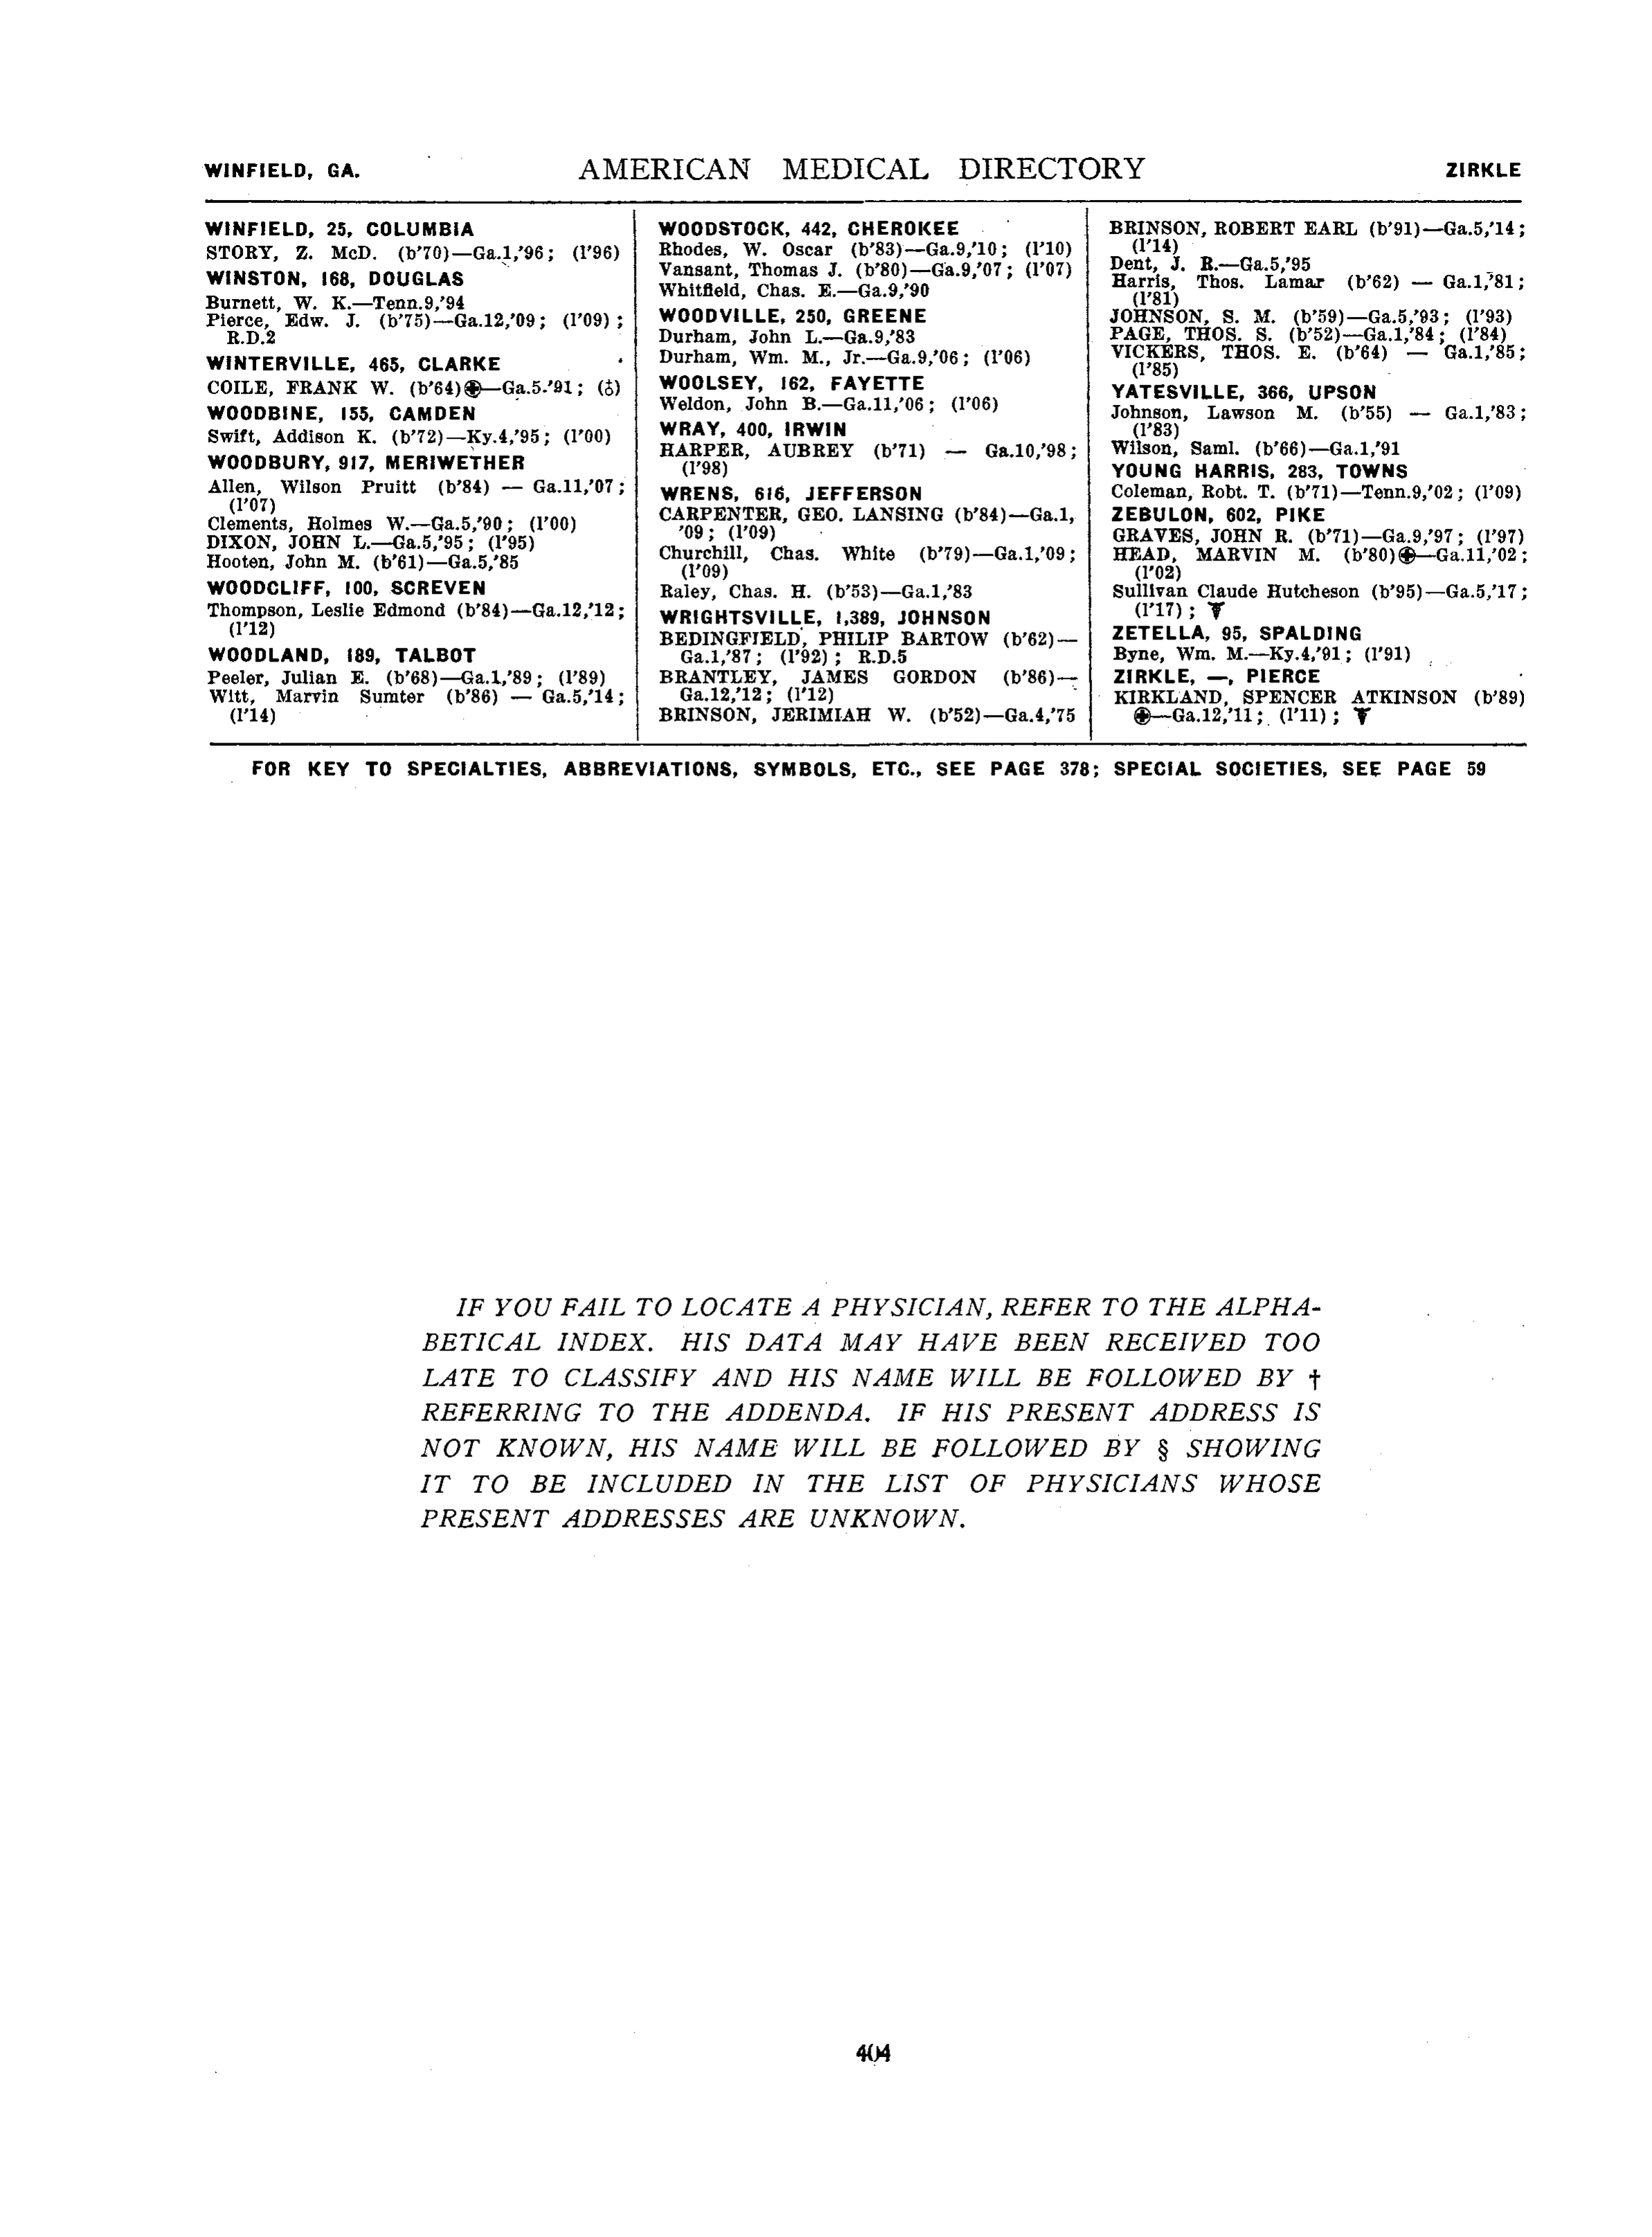

In [6]:
# Load single page
page_img = process_single_page(pdf_path, 27, DPI)
page_img

In [7]:
# Convert to grayscale
img_gray = cv2.cvtColor(np.array(page_img), cv2.COLOR_RGB2GRAY)

## save full page for reference (optional)
#page_fn = f"{stem}_p001.jpg"
#cv2.imwrite(str(pdf_out_dir / page_fn), img_gray, [int(cv2.IMWRITE_JPEG_QUALITY), 92])

# Free the PIL image immediately
del page_img
gc.collect()

20

detect_vertical_columns -> rows

Image dimensions: width=2387, height=3232


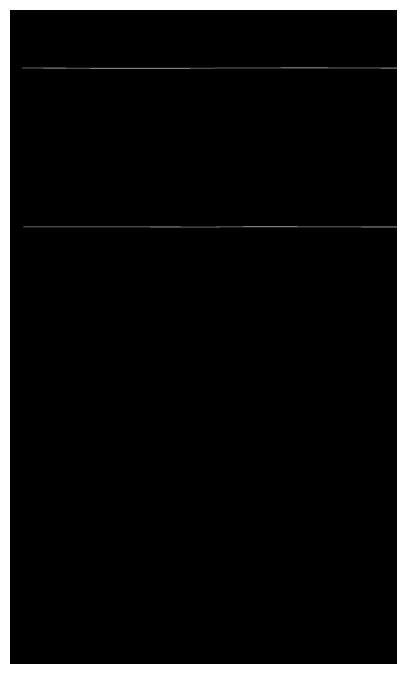

y=289, h_norm=0.125
y=290, h_norm=0.603
y=291, h_norm=1.000
y=292, h_norm=0.502
y=293, h_norm=0.267
y=1073, h_norm=0.144
y=1074, h_norm=0.902
y=1075, h_norm=0.997
y=1076, h_norm=0.281
[291, 1075]


[0, 291, 1075, 3232]

In [ ]:
img_in = img_gray.copy()
h, w = img_in.shape
print(f"Image dimensions: width={w}, height={h}")

binary = cv2.adaptiveThreshold(img_in, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                cv2.THRESH_BINARY_INV, 11, 2)
roi = binary[:, int(w*0.1):int(w*0.90)] 
h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (150, 1))
h_lines = cv2.morphologyEx(roi, cv2.MORPH_OPEN, h_kernel)
display_image(h_lines)
h_proj = np.sum(h_lines, axis=1)
h_norm = h_proj / (np.max(h_proj) + 1e-6)

# for y in range(len(h_norm)):
#     if h_norm[y] > 0.1:
#         print(f"y={y}, h_norm={h_norm[y]:.3f}")

peaks = [y for y in range(1, len(h_norm)-1) if h_norm[y] > 0.1 and h_norm[y] > h_norm[y-1] and h_norm[y] > h_norm[y+1]]
print(sorted(peaks))
clean_peaks = []
min_row_h = h // 12
if peaks:
    clean_peaks.append(peaks[0])
    for p in peaks[1:]:
        if p > clean_peaks[-1] + min_row_h: clean_peaks.append(p)
h_bounds = sorted(list(set([0] + clean_peaks + [h])))
h_bounds

detect_horizontal_rules

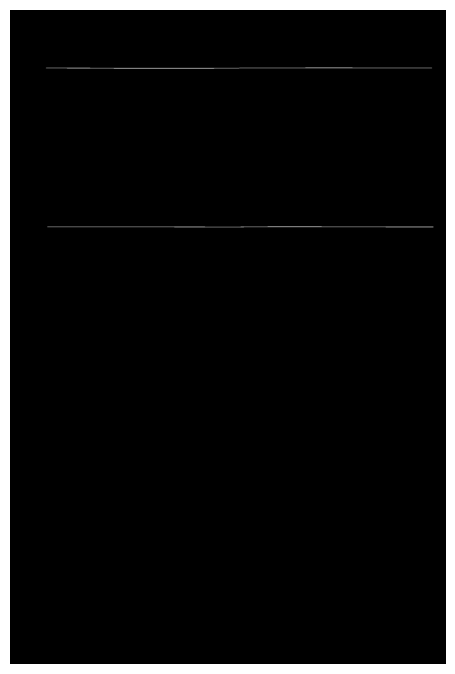

In [19]:
"""Refined skew-tolerant horizontal detection."""
column_gray = img_gray#img_gray[:, v_bounds[0]:v_bounds[1]]

h, w = column_gray.shape
#if h < 100 or w < 10: return [0, h]

shave = max(1, int(w * 0.05))
inner = column_gray[:, shave:w-shave] if w > 10 else column_gray
binary = cv2.adaptiveThreshold(inner, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                cv2.THRESH_BINARY_INV, 11, 2)

# Use the 'Narrow Beam' (10%) and 'Bridge' (Morph Close) logic
kernel_w = max(10, int(inner.shape[1] * 0.08))
h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_w, 1))

detected = cv2.morphologyEx(binary, cv2.MORPH_OPEN, h_kernel)
display_image(detected)


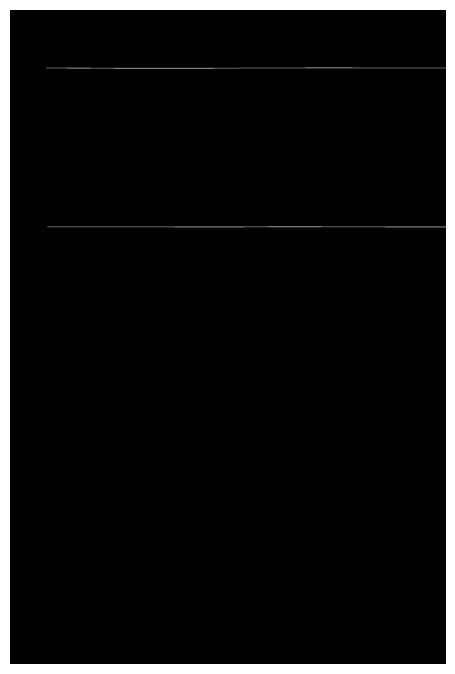

In [20]:
detected = cv2.morphologyEx(detected, cv2.MORPH_CLOSE, h_kernel, iterations=2)
display_image(detected)

In [26]:
y_proj = np.sum(detected, axis=1)
print(y_proj)
max_p = np.max(y_proj)
print(max_p)
#if max_p == 0: return [0, h]

peak_thresh = max_p * 0.1 # Lowered threshold for tilted rules
dividers = []
y = 0
while y < h:
    if y_proj[y] > peak_thresh:
        dividers.append(y)
        y += 60 # Skip ahead
    y += 1
h_bounds = sorted(list(set([0] + dividers + [h])))
h_bounds

[0 0 0 ... 0 0 0]
323085


[0, 68, 1039, 2248, 2656, 2765]